# Lab 1 — Titanic Exploratory Data Analysis

**Before you start:** copy this file to `Students/<YourStudentID>/Unit1/Lab1/U1_L1.ipynb` and work in the copy — don't edit this skeleton in place.

Full instructions are in `U1_L1_instructions.md`. Fill in every `# TODO` code cell, in order.
### Documentation checkpoint
For refernce you can begin with the [pandas documentation](https://pandas.pydata.org/docs/reference/index.html#api) or [Matplotlib documentation](https://matplotlib.org/stable/api/index.html).

## Step 1 — Load & Inspect

Already filled in for you, exactly as shown in class 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [21]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
df.shape

(891, 12)

## Step 2 — Data Quality

In [53]:
# TODO: report the missing values for every column
# Investigate: which DataFrame operation detects missing values and summarizes them by column?
df.isna().sum() # detects missing values and counts them by column


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [68]:
# TODO: report how many rows are duplicates
# Investigate: which DataFrame operation identifies repeated rows?
df.duplicated().sum() # cuenta las filas repetidas.

np.int64(0)

## Step 3 — Distributions

Pick at least 2 numeric columns and 1 categorical column. Choose and create appropriate distribution charts for each.

<Axes: ylabel='Frequency'>

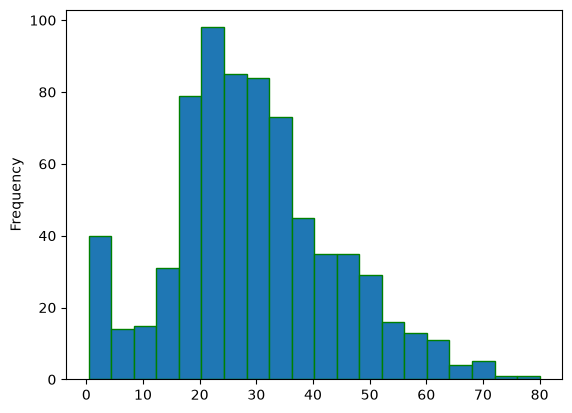

In [142]:
# TODO: plot the distribution of one numeric feature
# Investigate: choose an appropriate Matplotlib or pandas plotting method.
df["Age"].plot.hist(bins=20, edgecolor="green")

<Axes: ylabel='Frequency'>

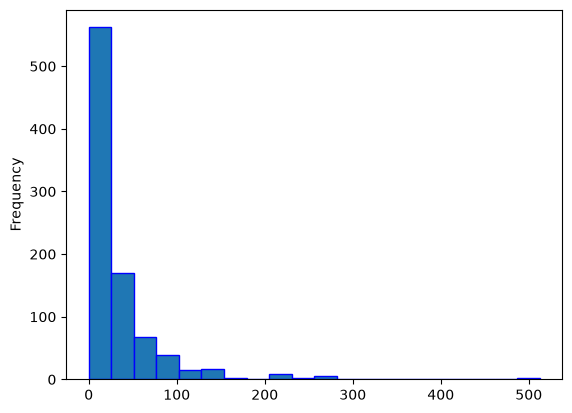

In [184]:
# TODO: plot the distribution of a second numeric feature
# Investigate: reuse or adapt a documented plotting method.
df["Fare"].plot.hist(bins=20, edgecolor="blue")

<Axes: xlabel='Sex'>

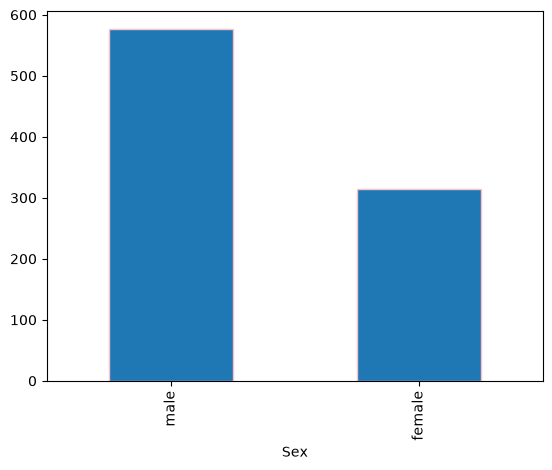

In [197]:
# TODO: plot the frequency of one categorical feature
# Investigate: find a way to count categories, then display those counts clearly.
df["Sex"].value_counts().plot.bar(edgecolor="pink")

## Step 4 — Relationships

Create at least 2 visualizations comparing a feature against `Survived`. Choose chart types that make the survival pattern readable.

<Axes: title={'center': 'Age'}, xlabel='Survived'>

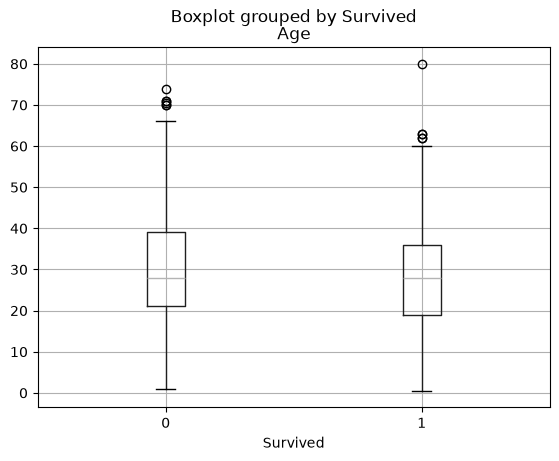

In [233]:
# TODO: create a visualization comparing one feature with survival
# Investigate: select a chart type that makes the comparison readable.
df.boxplot(column="Age", by="Survived" )

<Axes: title={'center': 'Fare'}, xlabel='Survived'>

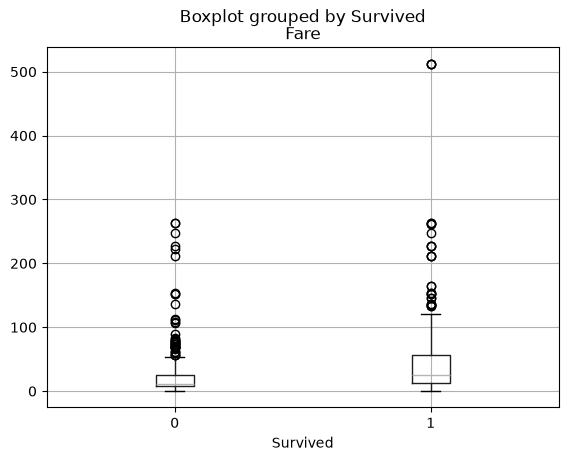

In [245]:
# TODO: create a second visualization comparing a different feature with survival
# Investigate: choose a chart that adds a distinct observation to the first one.
df.boxplot(column="Fare", by="Survived")

## Step 5 — Cleaning

Handle missing values, drop duplicates, encode categorical features, and scale numeric features.

In [ ]:
# TODO: handle missing values
# Decide: choose a defensible treatment for missing values and document it in Markdown.
# I field the missiong values with the median.

df["Age"] = df["Age"].fillna(df["Age"].median())


df = df.drop(columns=["Cabin"])

In [275]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q',
       'Embarked_S'],
      dtype='str')

In [281]:
# TODO: remove duplicate rows
# Investigate: find the DataFrame operation that removes repeated records.
df = df.drop_duplicates()


In [297]:
# TODO: transform categorical features into a numeric representation. Refer to CATEGORICAL ENCODING in ML_U1_C2.pdf 
# Investigate: choose an encoding approach appropriate for nominal categories.
# Check the output data types; your encoded features must be available for Step 6.
df = pd.get_dummies(df, columns=["Sex", "Embarked"], dtype=int)

KeyError: "None of [Index(['Sex', 'Embarked'], dtype='str')] are in the [columns]"

In [ ]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Sex_female       int64
Sex_male         int64
Embarked_C       int64
Embarked_Q       int64
Embarked_S       int64
dtype: object

In [298]:
# TODO: scale numeric features. Refer to FEATURE SCALING in ML_U1_C2.pdf
# Investigate: find a scaler, identify which columns it should receive, and preserve the DataFrame structure.
from sklearn.preprocessing import StandardScaler

## Step 6 — Correlation & Top Predictors

Refer to VISUALIZATION in ML_U1_C2.pdf for guidance on how to create the visualizations.

In [304]:
# TODO: build a correlation matrix using the relevant transformed features
# Investigate: determine which data types correlation can use.
corr = df.corr(numeric_only=True)
corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658,-0.042939,0.042939,-0.001205,-0.033606,0.022148
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.543351,-0.543351,0.168240,0.003650,-0.155660
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,-0.131900,0.131900,-0.243292,0.221009,0.081720
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.081163,0.081163,0.030248,-0.031415,-0.014665
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.114631,-0.114631,-0.059528,-0.026354,0.070941
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.245489,-0.245489,-0.011069,-0.081228,0.063036
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.182333,-0.182333,0.269335,-0.117216,-0.166603
Sex_female,-0.042939,0.543351,-0.131900,-0.081163,0.114631,0.245489,0.182333,1.000000,-1.000000,0.082853,0.074115,-0.125722
Sex_male,0.042939,-0.543351,0.131900,0.081163,-0.114631,-0.245489,-0.182333,-1.000000,1.000000,-0.082853,-0.074115,0.125722
Embarked_C,-0.001205,0.168240,-0.243292,0.030248,-0.059528,-0.011069,0.269335,0.082853,-0.082853,1.000000,-0.148258,-0.778359


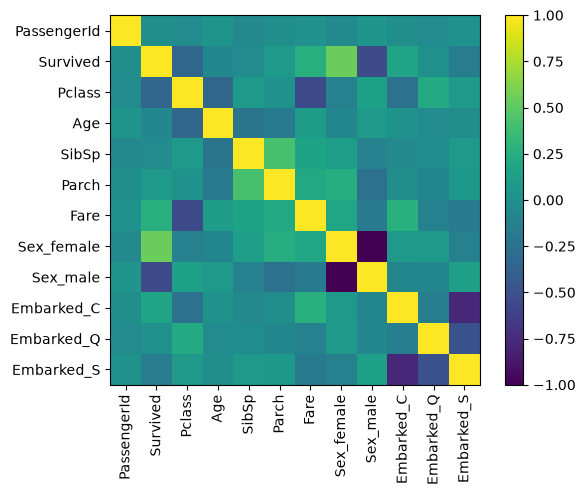

In [309]:
# TODO: visualize the correlation matrix and include a legend for the color scale
# Investigate: find a Matplotlib approach for displaying a two-dimensional numeric matrix.
import matplotlib.pyplot as plt

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()


In [310]:
# TODO: create a table ranking non-target features by their correlation with Survived
# Investigate: use absolute correlation strength for ranking, but retain the signed value in your final table.


In [311]:
# TODO: print the top 3 non-target features most correlated with Survived
# Investigate: make sure Survived itself is not one of your reported predictors.


## Step 7 — Save the cleaned dataset

In [312]:
# TODO: save the cleaned DataFrame as titanic_clean.csv in your Lab1 submission folder
# Investigate: look up the CSV export option that prevents the DataFrame index from being written as a column.
# Then confirm the file exists before submitting the lab.
